PHASE 1: DATA LOADING & EXPLORATORY DATA ANALYSIS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ── 1. Load Data ──────────────────────────────────────────
df_raw = pd.read_csv('vehicle_mileage_dataset (1).csv')
print("Shape:", df_raw.shape)
print("\nFirst 5 rows:")
print(df_raw.head())

Shape: (46, 12)

First 5 rows:
  Fuel type  Load(in kg) Condition of roads  Traffic conditions  Gear Changes  \
0    Petrol           60               Good                   1            18   
1    Petrol           60               Good                   2            20   
2    Petrol           60            Average                   2            22   
3    Petrol           60               Poor                   3            25   
4    Petrol           86               Good                   1            19   

   Hard Throttle  Hard braking  Ambient Temperature  Average Speed  \
0              5             3                   32           38.0   
1              6             4                   33           36.0   
2              7             5                   34           33.0   
3             10             7                   35           28.0   
4              6             3                   32           35.0   

   Fuel consumed(in ml)  Distance Travelled  Mileage  
0     

In [ ]:
# ── 2. Basic Info ─────────────────────────────────────────
print("\nColumn names:", df_raw.columns.tolist())
print("\nData types:\n", df_raw.dtypes)
print("\nMissing values:\n", df_raw.isnull().sum())
print("\nBasic statistics:\n", df_raw.describe())


Column names: ['Fuel type', 'Load(in kg)', 'Condition of roads', 'Traffic conditions', 'Gear Changes', 'Hard Throttle', 'Hard braking', 'Ambient Temperature', 'Average Speed', 'Fuel consumed(in ml)', 'Distance Travelled', 'Mileage']

Data types:
 Fuel type                object
Load(in kg)               int64
Condition of roads       object
Traffic conditions        int64
Gear Changes              int64
Hard Throttle             int64
Hard braking              int64
Ambient Temperature       int64
Average Speed           float64
Fuel consumed(in ml)      int64
Distance Travelled      float64
Mileage                 float64
dtype: object

Missing values:
 Fuel type               0
Load(in kg)             0
Condition of roads      0
Traffic conditions      0
Gear Changes            0
Hard Throttle           0
Hard braking            0
Ambient Temperature     0
Average Speed           0
Fuel consumed(in ml)    0
Distance Travelled      0
Mileage                 0
dtype: int64

Basic stat

In [ ]:
# ── 3. Filter Petrol Only & Drop Leakage Columns ─────────
df = df_raw[df_raw['Fuel type'] == 'Petrol'].copy()
df = df.drop(columns=['Fuel type', 'Fuel consumed(in ml)', 'Distance Travelled'])

In [ ]:
# ── 4. Encode Categorical Variables ──────────────────────
# Roads — text to ordinal
ordinal_map = {'Good': 2, 'Average': 1, 'Poor': 0}
df['Condition of roads'] = df['Condition of roads'].map(ordinal_map)

# Traffic — already numeric (1,2,3), remap to (0,1,2)
df['Traffic conditions'] = df['Traffic conditions'].map({1: 0, 2: 1, 3: 2})

# Verify
print("Missing values after encoding:\n", df.isnull().sum())
print("\nSample:\n", df.head())

Missing values after encoding:
 Load(in kg)            0
Condition of roads     0
Traffic conditions     0
Gear Changes           0
Hard Throttle          0
Hard braking           0
Ambient Temperature    0
Average Speed          0
Mileage                0
dtype: int64

Sample:
    Load(in kg)  Condition of roads  Traffic conditions  Gear Changes  \
0           60                   2                   0            18   
1           60                   2                   1            20   
2           60                   1                   1            22   
3           60                   0                   2            25   
4           86                   2                   0            19   

   Hard Throttle  Hard braking  Ambient Temperature  Average Speed  Mileage  
0              5             3                   32           38.0     38.0  
1              6             4                   33           36.0     36.0  
2              7             5                   34  

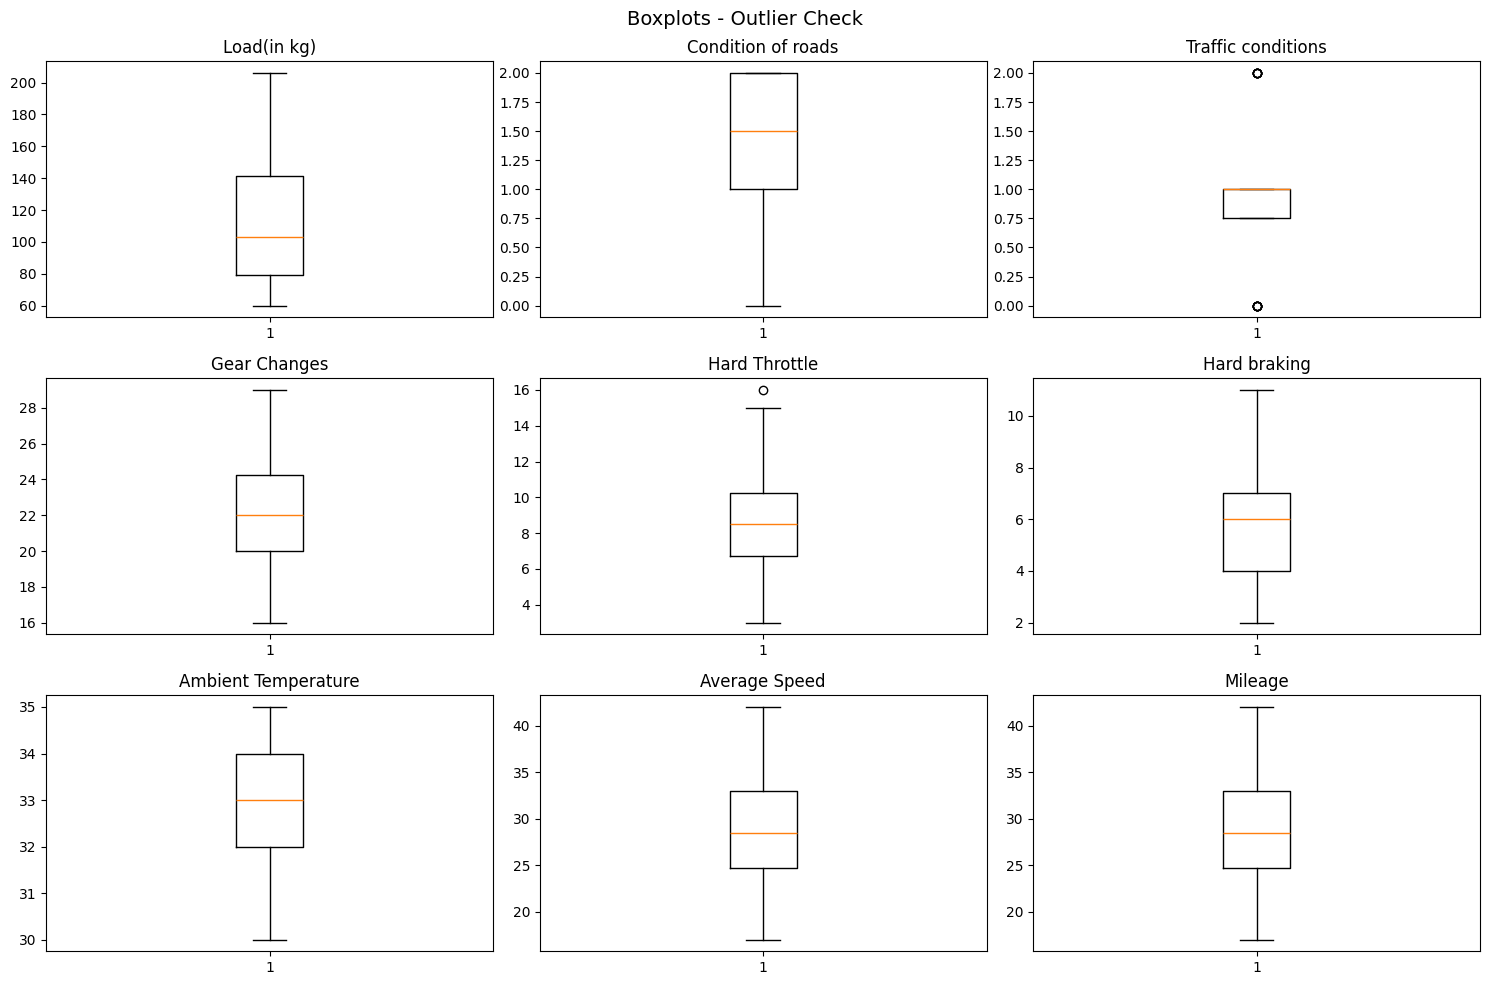

In [ ]:
# ── 5. Outlier Check (Boxplots) ───────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
plt.suptitle('Boxplots - Outlier Check', fontsize=14)
plt.tight_layout()
plt.show()


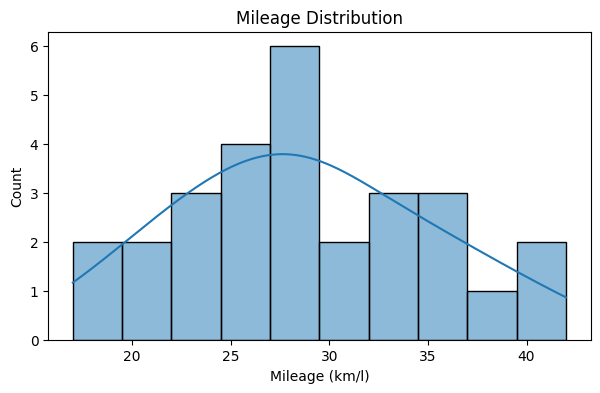


Phase 1 Complete. Shape: (28, 9)
   Load(in kg)  Condition of roads  Traffic conditions  Gear Changes  \
0           60                   2                   0            18   
1           60                   2                   1            20   
2           60                   1                   1            22   
3           60                   0                   2            25   
4           86                   2                   0            19   

   Hard Throttle  Hard braking  Ambient Temperature  Average Speed  Mileage  
0              5             3                   32           38.0     38.0  
1              6             4                   33           36.0     36.0  
2              7             5                   34           33.0     33.0  
3             10             7                   35           28.0     28.0  
4              6             3                   32           35.0     35.0  


In [ ]:
# ── 6. Distribution of Target Variable ───────────────────
plt.figure(figsize=(7, 4))
sns.histplot(df['Mileage'], kde=True, bins=10)
plt.title('Mileage Distribution')
plt.xlabel('Mileage (km/l)')
plt.show()

print("\nPhase 1 Complete. Shape:", df.shape)
print(df.head())

In [ ]:
df.columns.tolist()

['Load(in kg)',
 'Condition of roads',
 'Traffic conditions',
 'Gear Changes',
 'Hard Throttle',
 'Hard braking',
 'Ambient Temperature',
 'Average Speed',
 'Mileage']

PHASE 2: FEATURE ANALYSIS

In [ ]:
# ============================================================
# PHASE 2: FEATURE ANALYSIS
# ============================================================


from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

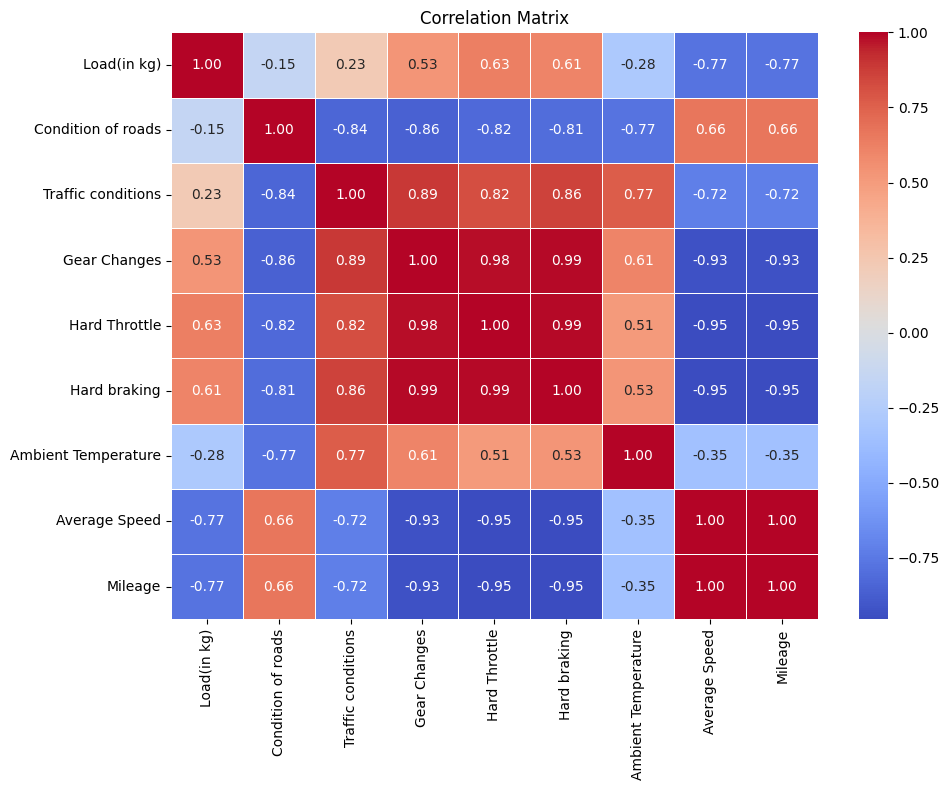


Correlation with Mileage (sorted):
Average Speed          1.000000
Condition of roads     0.664437
Ambient Temperature   -0.346918
Traffic conditions    -0.722890
Load(in kg)           -0.773237
Gear Changes          -0.929101
Hard braking          -0.947294
Hard Throttle         -0.954132
Name: Mileage, dtype: float64


In [ ]:
# ── 1. Correlation Matrix ─────────────────────────────────
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Correlation with Mileage sorted
print("\nCorrelation with Mileage (sorted):")
print(corr['Mileage'].drop('Mileage').sort_values(ascending=False))

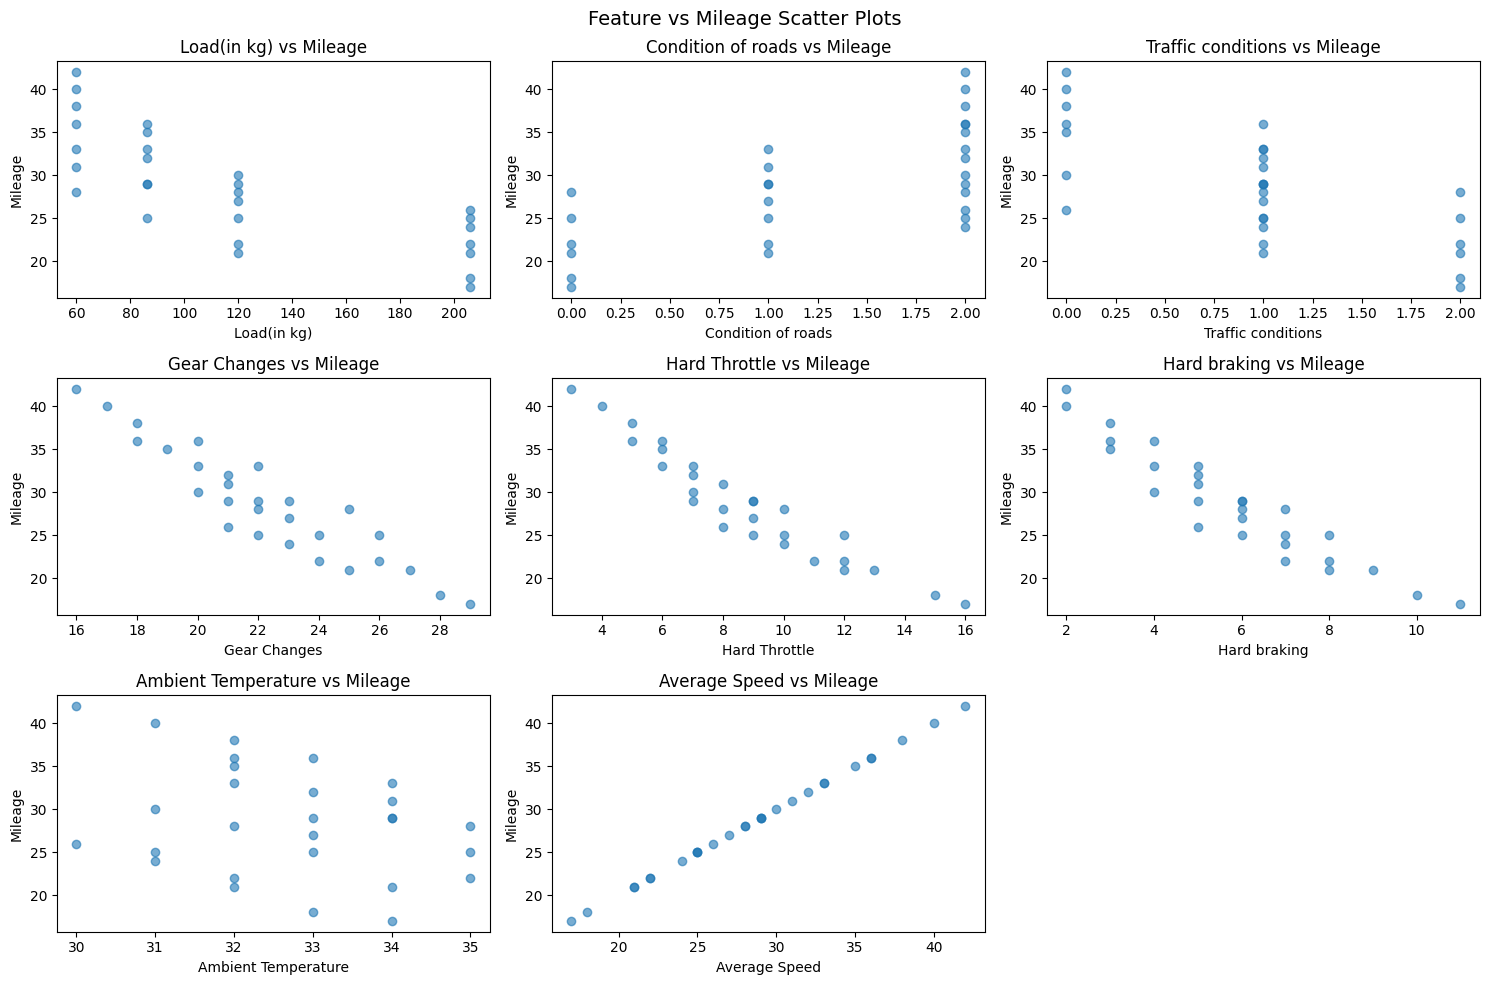

In [ ]:
#── 2. Scatter Plots ──────────────────────────────────────
features = [col for col in df.columns if col != 'Mileage']
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].scatter(df[col], df['Mileage'], alpha=0.6)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Mileage')
    axes[i].set_title(f'{col} vs Mileage')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature vs Mileage Scatter Plots', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ── 3. VIF Check ─────────────────────────────────────────
X = df.drop(columns=['Mileage'])
X_const = add_constant(X)
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i+1)
                   for i in range(X.shape[1])]
print("\nVIF Scores:")
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))


VIF Scores:
            Feature        VIF
       Gear Changes 109.079864
       Hard braking 105.484160
      Hard Throttle 101.440954
      Average Speed  41.499085
        Load(in kg)  22.440826
 Condition of roads  11.498448
 Traffic conditions  11.173460
Ambient Temperature  10.548910


In [ ]:
# ── 4. Feature Selection for Linear Model Only ────────────
# NOTE: VIF/multicollinearity only matters for Linear Regression.
# Ridge, Lasso, Random Forest, Gradient Boosting do NOT need
# feature removal — they handle multicollinearity internally.
# So we create TWO feature sets:
#   df_linear → reduced features (for Linear/Ridge/Lasso)
#   df_full   → all features     (for RF and GBM)

# FIXED CODE
cols_to_drop_for_linear = ['Average Speed', 'Hard braking', 'Gear Changes', 'Ambient Temperature']

df_linear = df.drop(columns=cols_to_drop_for_linear)

# FIX: Drop ONLY 'Average Speed' for the full dataset to prevent leakage in Trees/Boosting.
# It keeps all other multicollinear features intact.
df_full = df.drop(columns=['Average Speed'])

In [ ]:
# ── 5. Test: does 'Condition of roads' help linear models?
# Using cross_val_predict to avoid LOOCV NaN issue
temp_scaler = StandardScaler()

features_with    = ['Load(in kg)', 'Condition of roads',
                    'Traffic conditions', 'Hard Throttle']
features_without = ['Load(in kg)', 'Traffic conditions', 'Hard Throttle']

print("\n" + "="*55)
print("LOOCV TEST: Condition of roads — keep or drop?")
print("="*55)

for feat_set in [features_with, features_without]:
    X_temp = df_linear[feat_set]
    y_temp = df_linear['Mileage']
    X_temp_scaled = temp_scaler.fit_transform(X_temp)
    # cross_val_predict collects all predictions first,
    # then we compute R² once — avoids NaN from single-point folds
    y_pred_loo = cross_val_predict(LinearRegression(),
                                   X_temp_scaled, y_temp,
                                   cv=len(y_temp))   # cv=28 = LOOCV
    r2_loo = r2_score(y_temp, y_pred_loo)
    print(f"\nFeatures: {feat_set}")
    print(f"  LOOCV R²: {r2_loo:.4f}")

# ── Decision: drop 'Condition of roads' from linear set ──
# Lasso assigned it 0.0 coefficient → confirmed useless
df_linear = df_linear.drop(columns=['Condition of roads'])

print("\nLinear model features:", df_linear.columns.tolist())
print("Full model features  :", df_full.columns.tolist())
print("\nLinear set shape:", df_linear.shape)
print("Full set shape   :", df_full.shape)

# Final VIF on linear feature set
print("\nFinal VIF (linear feature set):")
X_lin = df_linear.drop(columns=['Mileage'])
X_lin_const = add_constant(X_lin)
vif_final = pd.DataFrame()
vif_final['Feature'] = X_lin.columns
vif_final['VIF'] = [variance_inflation_factor(X_lin_const.values, i+1)
                    for i in range(X_lin.shape[1])]
print(vif_final.sort_values('VIF', ascending=False).to_string(index=False))


LOOCV TEST: Condition of roads — keep or drop?

Features: ['Load(in kg)', 'Condition of roads', 'Traffic conditions', 'Hard Throttle']
  LOOCV R²: 0.9388

Features: ['Load(in kg)', 'Traffic conditions', 'Hard Throttle']
  LOOCV R²: 0.9447

Linear model features: ['Load(in kg)', 'Traffic conditions', 'Hard Throttle', 'Mileage']
Full model features  : ['Load(in kg)', 'Condition of roads', 'Traffic conditions', 'Gear Changes', 'Hard Throttle', 'Hard braking', 'Ambient Temperature', 'Mileage']

Linear set shape: (28, 4)
Full set shape   : (28, 8)

Final VIF (linear feature set):
           Feature      VIF
     Hard Throttle 8.587919
Traffic conditions 5.433558
       Load(in kg) 2.954386


PHASE 3: DATA AUGMENTATION

In [ ]:
# ============================================================
# PHASE 3: DATA AUGMENTATION (Interpolation-based)
# ============================================================

# ── 1. Lock original data as test set (never touch this) ──
df_real = df.copy()
print("Real data (test set) shape:", df_real.shape)

# ── 2. Interpolation-based Augmentation ───────────────────
# Why: Gaussian noise just jiggles existing points.
# Interpolation generates points *between* real observations,
# which is more meaningful and defensible.

# FIXED CODE
np.random.seed(42)
new_rows = []
# FIX: Use df_linear instead of the raw df
for i in range(len(df_linear)):
    for j in range(i + 1, len(df_linear)):
        alpha = np.random.uniform(0.3, 0.7)
        interpolated = alpha * df_linear.iloc[i] + (1 - alpha) * df_linear.iloc[j]
        new_rows.append(interpolated)
df_interp = pd.DataFrame(new_rows, columns=df_linear.columns)
df_interp['Traffic conditions'] = df_interp['Traffic conditions'].round().astype(int)
df_augmented = pd.concat([df_linear, df_interp], ignore_index=True)

print(f"Original rows         : {len(df)}")
print(f"Interpolated rows     : {len(df_interp)}")
print(f"Total augmented rows  : {len(df_augmented)}")
print(f"\nAugmented data statistics:")
print(df_augmented.describe())

# Also create augmented version of full feature set for RF/GBM
np.random.seed(42)
new_rows_full = []
for i in range(len(df_full)):
    for j in range(i + 1, len(df_full)):
        alpha = np.random.uniform(0.3, 0.7)
        interpolated = alpha * df_full.iloc[i] + (1 - alpha) * df_full.iloc[j]
        new_rows_full.append(interpolated)

df_interp_full = pd.DataFrame(new_rows_full, columns=df_full.columns)
df_interp_full['Traffic conditions'] = df_interp_full['Traffic conditions'].round().astype(int)
df_interp_full['Condition of roads'] = df_interp_full['Condition of roads'].round().astype(int)

df_augmented_full = pd.concat([df_full, df_interp_full], ignore_index=True)

print(f"\nFull feature augmented set shape: {df_augmented_full.shape}")

# df_real stays the same (28 real rows, used for testing both sets)

Real data (test set) shape: (28, 9)
Original rows         : 28
Interpolated rows     : 378
Total augmented rows  : 406

Augmented data statistics:
       Load(in kg)  Traffic conditions  Hard Throttle     Mileage
count   406.000000          406.000000     406.000000  406.000000
mean    118.022826            0.963054       8.702293   28.651853
std      40.376199            0.609484       2.296991    4.688614
min      60.000000            0.000000       3.000000   17.000000
25%      86.000000            1.000000       7.004933   25.449192
50%     109.267002            1.000000       8.493965   28.429298
75%     149.641570            1.000000      10.121072   31.953667
max     206.000000            2.000000      16.000000   42.000000

Full feature augmented set shape: (406, 8)


In [ ]:
# ============================================================
# PHASE 4: PREPROCESSING
# ============================================================

from sklearn.preprocessing import StandardScaler

# ── Two separate train sets ───────────────────────────────
# Linear/Ridge/Lasso → trained on reduced feature augmented set
# RF/GBM             → trained on full feature augmented set

# FIXED CODE
# Linear feature set
df_train_linear = df_augmented.copy()
# FIX: Use df_linear for testing so the columns match the training set
df_test_linear = df_linear.copy()

X_train_linear = df_train_linear.drop(columns=['Mileage'])
y_train_linear = df_train_linear['Mileage']
X_test_linear  = df_test_linear.drop(columns=['Mileage'])
y_test_linear  = df_test_linear['Mileage']

# ── Full feature set ──────────────────────────────────────
# Test set must also have all 8 features → use df_real (which is df_full copy)
df_train_full = df_augmented_full.copy()    # 406 rows, 8 features
df_test_full  = df_full.copy()              # 28 rows,  8 features
# Note: df_full = df before any drops, already encoded

X_train_full = df_train_full.drop(columns=['Mileage'])
y_train_full = df_train_full['Mileage']
X_test_full  = df_test_full.drop(columns=['Mileage'])
y_test_full  = df_test_full['Mileage']

# ── Scale both sets separately ────────────────────────────
scaler_linear = StandardScaler()
X_train_linear_scaled = scaler_linear.fit_transform(X_train_linear)
X_test_linear_scaled  = scaler_linear.transform(X_test_linear)

scaler_full = StandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_test_full_scaled  = scaler_full.transform(X_test_full)

# Convert back to dataframes
X_train_linear_scaled = pd.DataFrame(X_train_linear_scaled,
                                      columns=X_train_linear.columns)
X_test_linear_scaled  = pd.DataFrame(X_test_linear_scaled,
                                      columns=X_test_linear.columns)
X_train_full_scaled   = pd.DataFrame(X_train_full_scaled,
                                      columns=X_train_full.columns)
X_test_full_scaled    = pd.DataFrame(X_test_full_scaled,
                                      columns=X_test_full.columns)

print("Linear train shape:", X_train_linear_scaled.shape)
print("Linear test shape :", X_test_linear_scaled.shape)
print("Full train shape  :", X_train_full_scaled.shape)
print("Full test shape   :", X_test_full_scaled.shape)

print("\nLinear features:", X_train_linear.columns.tolist())
print("Full features  :", X_train_full.columns.tolist())

Linear train shape: (406, 3)
Linear test shape : (28, 3)
Full train shape  : (406, 7)
Full test shape   : (28, 7)

Linear features: ['Load(in kg)', 'Traffic conditions', 'Hard Throttle']
Full features  : ['Load(in kg)', 'Condition of roads', 'Traffic conditions', 'Gear Changes', 'Hard Throttle', 'Hard braking', 'Ambient Temperature']


Linear Regression trained on reduced features ✓
Ridge Regression trained on reduced features ✓
Lasso Regression trained on reduced features ✓
Random Forest trained on full features ✓
Gradient Boosting trained on full features ✓

EVALUATION ON REAL TEST SET (28 rows)

Linear Regression:
  R²   : 0.9597
  RMSE : 1.2734
  MAE  : 1.0311

Ridge Regression:
  R²   : 0.9598
  RMSE : 1.2715
  MAE  : 1.0299

Lasso Regression:
  R²   : 0.9587
  RMSE : 1.2893
  MAE  : 1.0452

Random Forest:
  R²   : 0.9775
  RMSE : 0.9521
  MAE  : 0.8181

Gradient Boosting:
  R²   : 0.9945
  RMSE : 0.4686
  MAE  : 0.4192

5-FOLD CV ON AUGMENTED TRAINING DATA

Linear Regression (reduced features):
  CV R²   : 0.9585 ± 0.0043
  CV RMSE : 0.9446 ± 0.0276

Ridge Regression (reduced features):
  CV R²   : 0.9585 ± 0.0045
  CV RMSE : 0.9448 ± 0.0284

Lasso Regression (reduced features):
  CV R²   : 0.9578 ± 0.0042
  CV RMSE : 0.9528 ± 0.0407

Random Forest (full features):
  CV R²   : 0.9598 ± 0.0074
  CV RMSE : 0.9255

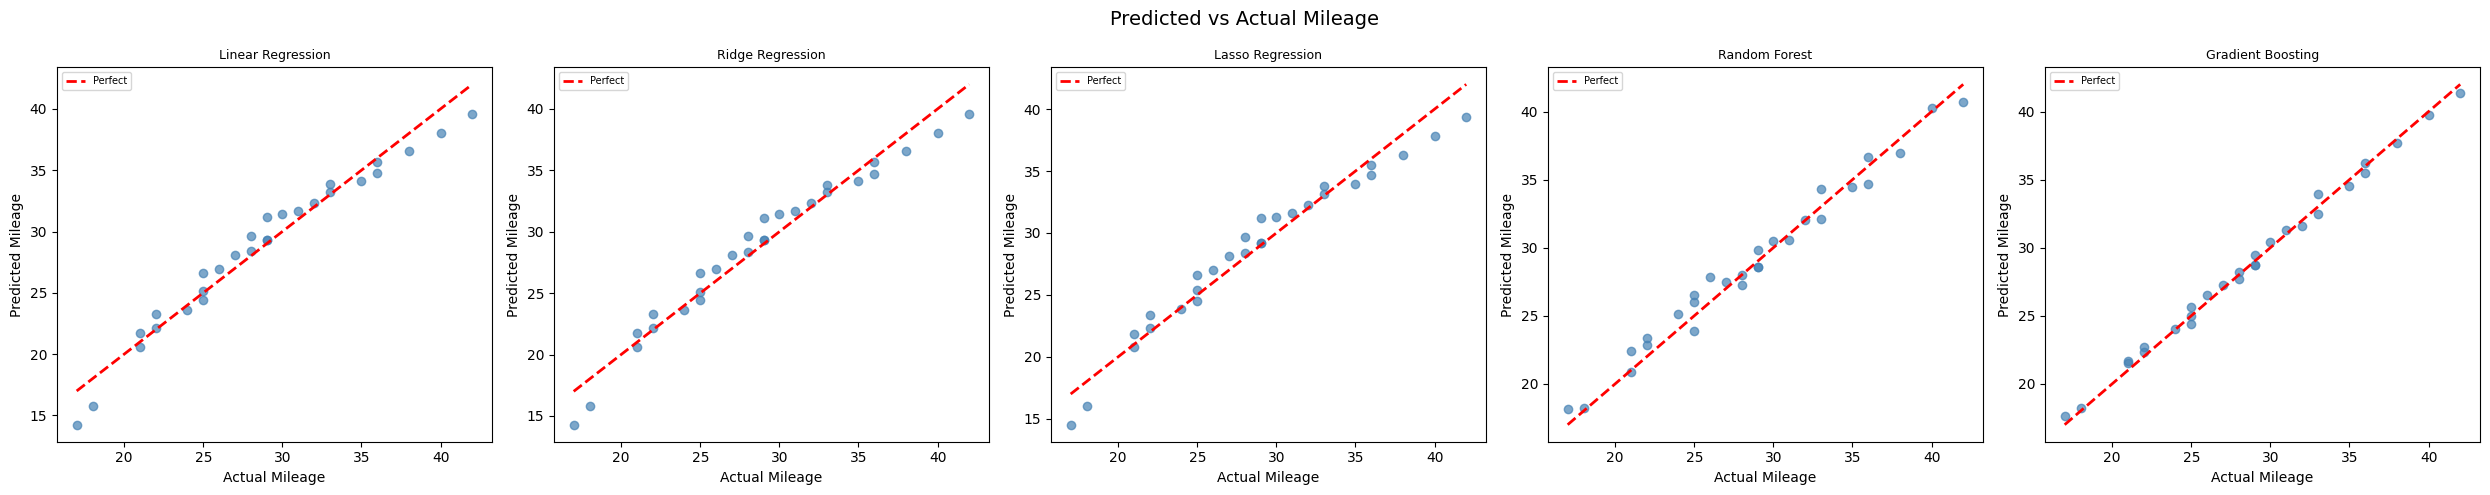

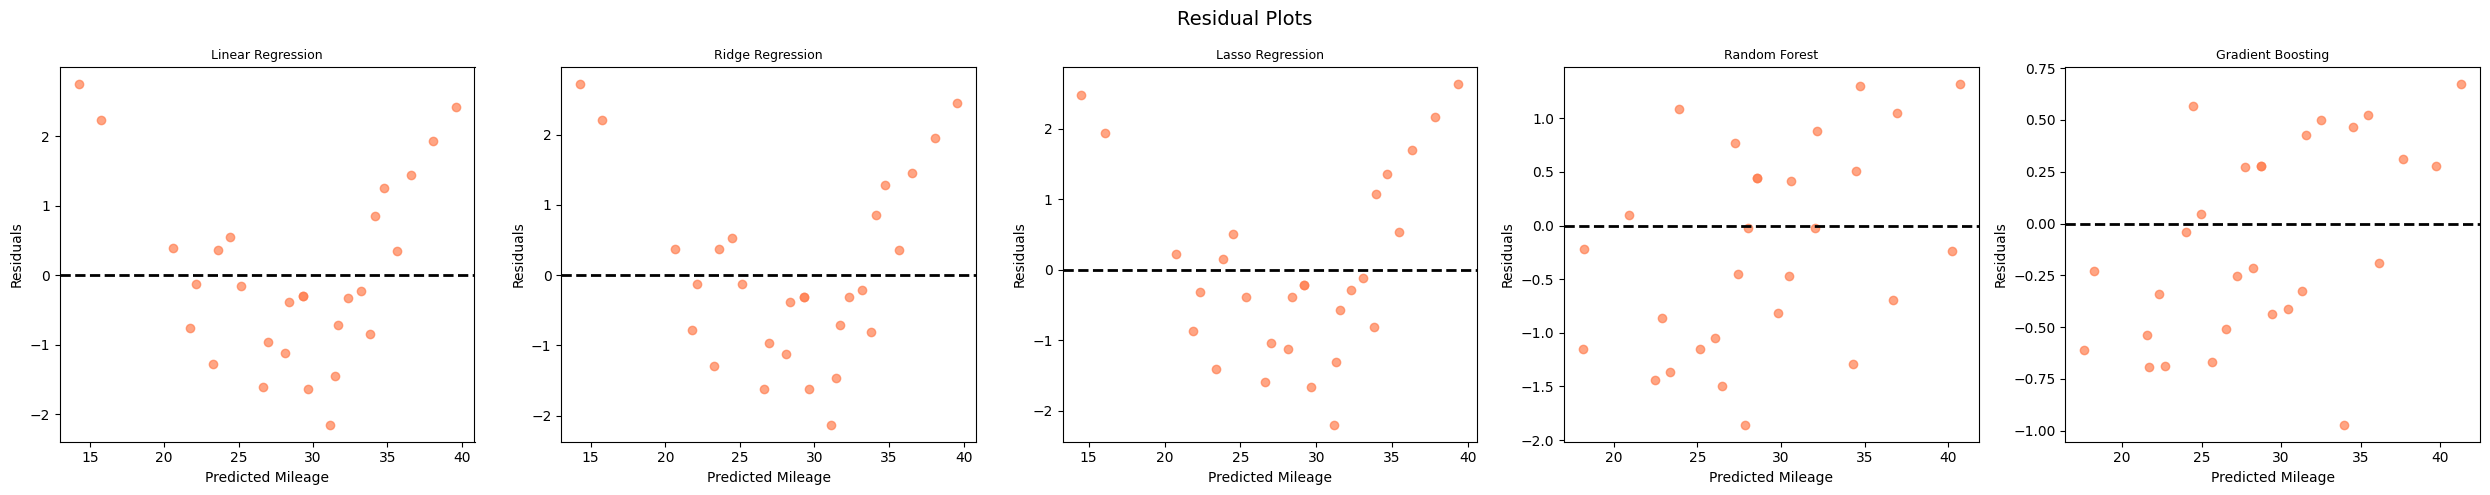

In [ ]:
# ============================================================
# PHASE 5: MODEL BUILDING + EVALUATION
# ============================================================

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold
import numpy as np

# ── 1. Define Models with their correct feature sets ──────
# Linear models → reduced features (no multicollinearity)
# Tree models   → full features    (immune to multicollinearity)

linear_models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Lasso Regression'  : Lasso(alpha=0.1),
}

tree_models = {
    'Random Forest'     : RandomForestRegressor(n_estimators=100,
                                                 max_depth=4,
                                                 random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100,
                                                     max_depth=3,
                                                     learning_rate=0.05,
                                                     random_state=42),
}

# ── 2. Train All Models ───────────────────────────────────
trained_models = {}

for name, model in linear_models.items():
    model.fit(X_train_linear_scaled, y_train_linear)
    trained_models[name] = model
    print(f"{name} trained on reduced features ✓")

for name, model in tree_models.items():
    model.fit(X_train_full_scaled, y_train_full)
    trained_models[name] = model
    print(f"{name} trained on full features ✓")

# ── 3. Test Set Evaluation ────────────────────────────────
print("\n" + "="*60)
print("EVALUATION ON REAL TEST SET (28 rows)")
print("="*60)

results = {}

for name, model in trained_models.items():
    # Use correct test set per model type
    if name in linear_models:
        y_pred = model.predict(X_test_linear_scaled)
        y_true = y_test_linear
    else:
        y_pred = model.predict(X_test_full_scaled)
        y_true = y_test_full

    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    results[name] = {'R2': r2, 'RMSE': rmse, 'MAE': mae}
    print(f"\n{name}:")
    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")

# ── 4. 5-Fold CV on Augmented Training Data ───────────────
print("\n" + "="*60)
print("5-FOLD CV ON AUGMENTED TRAINING DATA")
print("="*60)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in linear_models.items():
    fresh = model.__class__(**model.get_params())
    cv_r2   = cross_val_score(fresh, X_train_linear_scaled,
                               y_train_linear, cv=kf, scoring='r2')
    cv_rmse = cross_val_score(fresh, X_train_linear_scaled,
                               y_train_linear, cv=kf,
                               scoring='neg_root_mean_squared_error')
    print(f"\n{name} (reduced features):")
    print(f"  CV R²   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f"  CV RMSE : {-cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")

for name, model in tree_models.items():
    fresh = model.__class__(**model.get_params())
    cv_r2   = cross_val_score(fresh, X_train_full_scaled,
                               y_train_full, cv=kf, scoring='r2')
    cv_rmse = cross_val_score(fresh, X_train_full_scaled,
                               y_train_full, cv=kf,
                               scoring='neg_root_mean_squared_error')
    print(f"\n{name} (full features):")
    print(f"  CV R²   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f"  CV RMSE : {-cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")

# 5. LOOCV on Real Data (fixed uses cross_val_predict)
print("\n" + "="*60)
print("LEAVE-ONE-OUT CV ON 28 REAL DATA POINTS")
print("(cross_val_predict used to avoid NaN in R²)")
print("="*60)

# FIX: We already created the perfectly scaled real test sets in Phase 4!
# We just use X_test_linear_scaled and X_test_full_scaled.
y_real = y_test_linear.values # The target is the same for both sets
n_real = len(y_real) # 28 = LOOCV

for name, model in linear_models.items():
    fresh = model.__class__(**model.get_params())
    # FIX: Pass the correct pre-scaled dataset
    y_loo = cross_val_predict(fresh, X_test_linear_scaled, y_real, cv=n_real)
    r2_loo = r2_score(y_real, y_loo)
    rmse_loo = np.sqrt(mean_squared_error(y_real, y_loo))
    print(f"\n{name}:")
    print(f"  LOOCV R2   : {r2_loo:.4f}")
    print(f"  LOOCV RMSE : {rmse_loo:.4f}")

for name, model in tree_models.items():
    fresh = model.__class__(**model.get_params())
    # FIX: Pass the correct pre-scaled dataset
    y_loo = cross_val_predict(fresh, X_test_full_scaled, y_real, cv=n_real)
    r2_loo = r2_score(y_real, y_loo)
    rmse_loo = np.sqrt(mean_squared_error(y_real, y_loo))
    print(f"\n{name}:")
    print(f"  LOOCV R2   : {r2_loo:.4f}")
    print(f"  LOOCV RMSE : {rmse_loo:.4f}")

# ── 6. Feature Coefficients (linear models) ───────────────
print("\n" + "="*60)
print("FEATURE COEFFICIENTS (Linear Models)")
print("="*60)
for name in linear_models:
    model = trained_models[name]
    print(f"\n{name}:")
    for feat, coef in zip(X_train_linear.columns, model.coef_):
        print(f"  {feat:25s}: {coef:.4f}")

# ── 7. Feature Importances (tree models) ──────────────────
print("\n" + "="*60)
print("FEATURE IMPORTANCES (Tree Models)")
print("="*60)
for name in tree_models:
    model = trained_models[name]
    print(f"\n{name}:")
    for feat, imp in zip(X_train_full.columns, model.feature_importances_):
        print(f"  {feat:25s}: {imp:.4f}")

# ── 8. Predicted vs Actual Plots ──────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, (name, model) in zip(axes, trained_models.items()):
    if name in linear_models:
        y_pred = model.predict(X_test_linear_scaled)
        y_true = y_test_linear
    else:
        y_pred = model.predict(X_test_full_scaled)
        y_true = y_test_full
    ax.scatter(y_true, y_pred, alpha=0.7, color='steelblue')
    ax.plot([y_true.min(), y_true.max()],
            [y_true.min(), y_true.max()],
            'r--', linewidth=2, label='Perfect')
    ax.set_xlabel('Actual Mileage')
    ax.set_ylabel('Predicted Mileage')
    ax.set_title(name, fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle('Predicted vs Actual Mileage', fontsize=14)
plt.tight_layout()
plt.show()

# ── 9. Residual Plots ─────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, (name, model) in zip(axes, trained_models.items()):
    if name in linear_models:
        y_pred    = model.predict(X_test_linear_scaled)
        y_true    = y_test_linear
    else:
        y_pred    = model.predict(X_test_full_scaled)
        y_true    = y_test_full
    residuals = y_true.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.7, color='coral')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=2)
    ax.set_xlabel('Predicted Mileage')
    ax.set_ylabel('Residuals')
    ax.set_title(name, fontsize=9)
plt.suptitle('Residual Plots', fontsize=14)
plt.tight_layout()
plt.show()

UNIVARIATE CURVE FITTING (each feature vs Mileage)

Feature: Load(in kg)
  Degree             R²     RMSE Equation
  ------------------------------------------------------------
  Linear         0.5979   4.0220  y = -0.089x +39.149
  Quadratic      0.6577   3.7110  y = +0.001x^2 -0.286x +50.165
  Cubic          0.6591   3.7033  y = +0.000x^3 -0.001x^2 -0.040x +41.805

Feature: Traffic conditions
  Degree             R²     RMSE Equation
  ------------------------------------------------------------
  Linear         0.5226   4.3826  y = -6.738x +35.140
  Quadratic      0.5231   4.3801  y = +0.293x^2 -7.312x +35.286
  Cubic          0.5231   4.3801  y = +0.430x^3 -0.996x^2 -6.452x +35.286

Feature: Hard Throttle
  Degree             R²     RMSE Equation
  ------------------------------------------------------------
  Linear         0.9104   1.8989  y = -1.943x +45.572
  Quadratic      0.9389   1.5684  y = +0.088x^2 -3.600x +52.449
  Cubic          0.9395   1.5601  y = -0.004x^3 +0.192x^2

/tmp/ipykernel_15082/3889499045.py:47: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_vals, y_vals, deg)


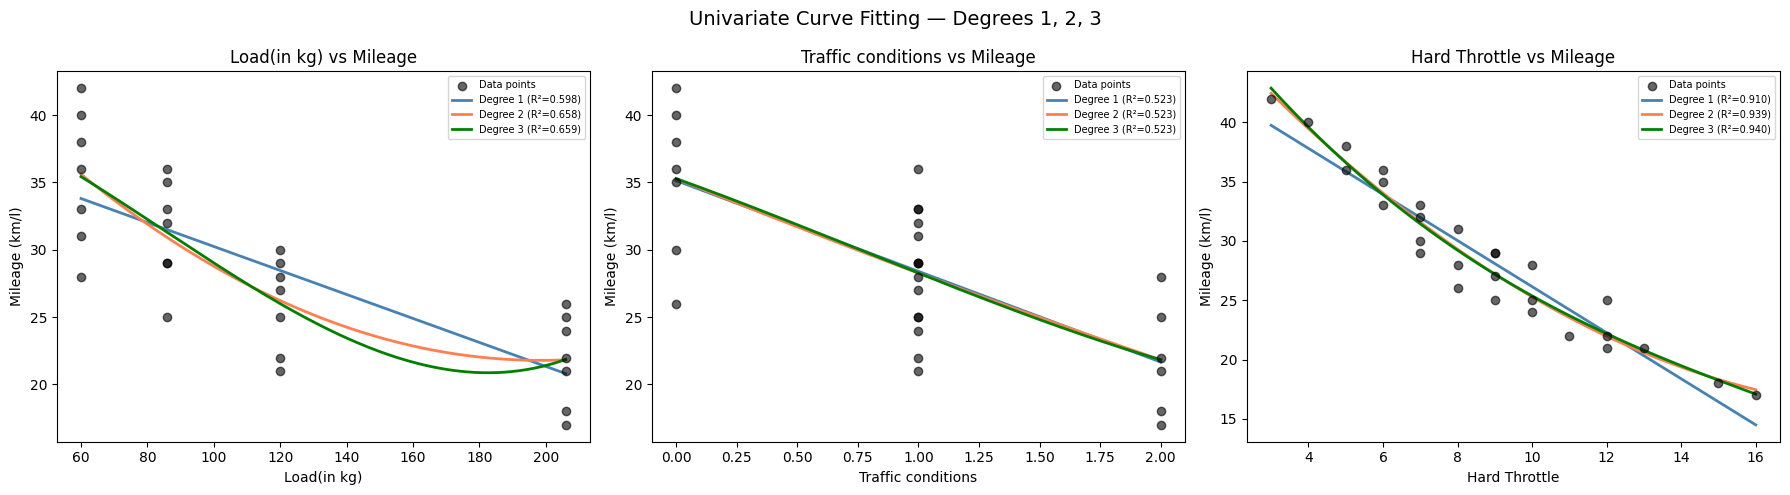


MULTIVARIATE POLYNOMIAL CURVE FITTING
(All 3 features: Load, Traffic, Hard Throttle)

Degree 1 (Linear) - 3 terms:
 Test R2    : 0.9597
 Test RMSE  : 1.2734
 LOOCV R2   : 0.9447
 LOOCV RMSE : 1.4920

Degree 2 (Quadratic) - 9 terms:
 Test R2    : 0.9859
 Test RMSE  : 0.7540
 LOOCV R2   : 0.9890
 LOOCV RMSE : 0.6660

Degree 3 (Cubic) - 19 terms:
 Test R2    : 0.9875
 Test RMSE  : 0.7093
 LOOCV R2   : 0.8859
 LOOCV RMSE : 2.1425


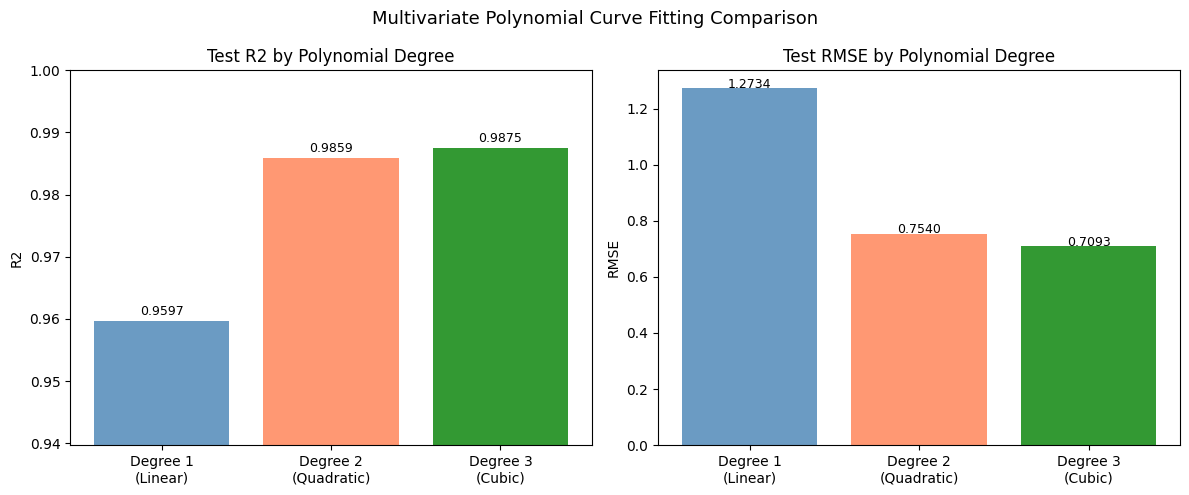


FINAL FITTED EQUATION (Linear Degree 1)

Mileage = 28.6519  -1.3933 x (Load(in kg))  -0.1832 x (Traffic conditions)  -3.4740 x (Hard Throttle)

Note: Coefficients are on SCALED features (mean=0, std=1).
Interpretation: Negative coefficient = increasing this feature REDUCES mileage.

CURVE FITTING CONCLUSION
Best polynomial degree : Degree 3 (Cubic)
Test R2                : 0.9875
LOOCV R2               : 0.8859

- Hard Throttle shows the strongest individual curve fit, confirming it is the dominant predictor of mileage.
- Load shows a moderately strong negative relationship.
- Traffic conditions shows a weaker but consistent effect.
- Higher degree polynomials fit the training data better but risk overfitting on a small dataset (notice LOOCV R2 dropping on Cubic).
- Degree 1 (linear) or Degree 2 (quadratic) remain the most defensible choices.



In [ ]:
# ============================================================
# PHASE 5.5: CURVE FITTING
# ============================================================
# Curve fitting finds the best mathematical equation describing
# the relationship between features and mileage.
# We test polynomial degrees 1, 2, 3 on:
#   (a) Each individual feature vs Mileage (univariate)
#   (b) Full feature set (multivariate polynomial)
# ============================================================

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_predict
import scipy.stats as stats

# ── 1. Univariate Curve Fitting ───────────────────────────
# Fit degree 1, 2, 3 polynomials for each feature vs Mileage
# Use the REAL 28 data points (unscaled) for interpretability

print("=" * 65)
print("UNIVARIATE CURVE FITTING (each feature vs Mileage)")
print("=" * 65)

fit_features = ['Load(in kg)', 'Traffic conditions', 'Hard Throttle']
degrees      = [1, 2, 3]
degree_labels = {1: 'Linear', 2: 'Quadratic', 3: 'Cubic'}
colors_deg   = {1: 'steelblue', 2: 'coral', 3: 'green'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, fit_features):
    x_vals = df_real[feat].values
    y_vals = df_real['Mileage'].values
    x_plot = np.linspace(x_vals.min(), x_vals.max(), 200)

    ax.scatter(x_vals, y_vals, color='black', alpha=0.6,
               zorder=5, label='Data points')

    print(f"\nFeature: {feat}")
    print(f"  {'Degree':<12} {'R²':>8} {'RMSE':>8} {'Equation'}")
    print(f"  {'-'*60}")

    for deg in degrees:
        # Fit polynomial
        coeffs = np.polyfit(x_vals, y_vals, deg)
        poly   = np.poly1d(coeffs)
        y_pred = poly(x_vals)

        r2   = r2_score(y_vals, y_pred)
        rmse = np.sqrt(mean_squared_error(y_vals, y_pred))

        # Build equation string
        terms = []
        for i, c in enumerate(coeffs):
            power = deg - i
            if power == 0:
                terms.append(f"{c:+.3f}")
            elif power == 1:
                terms.append(f"{c:+.3f}x")
            else:
                terms.append(f"{c:+.3f}x^{power}")
        eq_str = "y = " + " ".join(terms)

        print(f"  {degree_labels[deg]:<12} {r2:>8.4f} {rmse:>8.4f}  {eq_str}")

        # Plot curve
        ax.plot(x_plot, poly(x_plot),
                color=colors_deg[deg], linewidth=2,
                label=f'Degree {deg} (R²={r2:.3f})')

    ax.set_xlabel(feat)
    ax.set_ylabel('Mileage (km/l)')
    ax.set_title(f'{feat} vs Mileage')
    ax.legend(fontsize=7)

plt.suptitle('Univariate Curve Fitting — Degrees 1, 2, 3', fontsize=14)
plt.tight_layout()
plt.show()

# ── 2. Multivariate Polynomial Regression ─────────────────
# Fit the full 3-feature set with polynomial degrees 1, 2, 3
# Using augmented training data, evaluated on real test set

print("\n" + "="*65)
print("MULTIVARIATE POLYNOMIAL CURVE FITTING")
print("(All 3 features: Load, Traffic, Hard Throttle)")
print("="*65)

poly_results = {}
for deg in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('model', LinearRegression())
    ])

    # Train on augmented data
    pipe.fit(X_train_linear_scaled, y_train_linear)

    # Evaluate on real test set
    y_pred_test = pipe.predict(X_test_linear_scaled)
    r2_test = r2_score(y_test_linear, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test_linear, y_pred_test))

    # LOOCV on real data (FIXED LINE HERE)
    y_loo = cross_val_predict(
        Pipeline([
            ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
            ('model', LinearRegression())
        ]),
        X_test_linear_scaled, y_real, cv=n_real)

    r2_loo = r2_score(y_real, y_loo)
    rmse_loo = np.sqrt(mean_squared_error(y_real, y_loo))
    n_features_out = pipe.named_steps['poly'].n_output_features_

    poly_results[deg] = {
        'Test R2'    : r2_test,
        'Test RMSE'  : rmse_test,
        'LOOCV R2'   : r2_loo,
        'LOOCV RMSE' : rmse_loo,
        'N terms'    : n_features_out
    }

    print(f"\nDegree {deg} ({degree_labels[deg]}) - {n_features_out} terms:")
    print(f" Test R2    : {r2_test:.4f}")
    print(f" Test RMSE  : {rmse_test:.4f}")
    print(f" LOOCV R2   : {r2_loo:.4f}")
    print(f" LOOCV RMSE : {rmse_loo:.4f}")

# 3. Comparison Bar Chart
poly_df = pd.DataFrame(poly_results).T
poly_df.index = ['Degree 1\n(Linear)', 'Degree 2\n(Quadratic)', 'Degree 3\n(Cubic)']

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].bar(poly_df.index, poly_df['Test R2'], color=['steelblue', 'coral', 'green'], alpha=0.8)
for i, v in enumerate(poly_df['Test R2']):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)
axes[0].set_title('Test R2 by Polynomial Degree')
axes[0].set_ylabel('R2')
axes[0].set_ylim([poly_df['Test R2'].min() - 0.02, 1.0])

axes[1].bar(poly_df.index, poly_df['Test RMSE'], color=['steelblue', 'coral', 'green'], alpha=0.8)
for i, v in enumerate(poly_df['Test RMSE']):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)
axes[1].set_title('Test RMSE by Polynomial Degree')
axes[1].set_ylabel('RMSE')

plt.suptitle('Multivariate Polynomial Curve Fitting Comparison', fontsize=13)
plt.tight_layout()
plt.show()

# 4. Best Equation (Degree 1 - most interpretable)
print("\n" + "="*65)
print("FINAL FITTED EQUATION (Linear Degree 1)")
print("="*65)

lr_final = LinearRegression()
lr_final.fit(X_train_linear_scaled, y_train_linear)
feat_names = X_train_linear.columns.tolist()

print(f"\nMileage = {lr_final.intercept_:.4f}", end="")
for feat, coef in zip(feat_names, lr_final.coef_):
    sign = "+" if coef >= 0 else ""
    print(f" {sign} {coef:.4f} x ({feat})", end="")
print("\n\nNote: Coefficients are on SCALED features (mean=0, std=1).")
print("Interpretation: Negative coefficient = increasing this feature REDUCES mileage.")

# 5. Curve Fitting Conclusion
best_deg = max(poly_results, key=lambda d: poly_results[d]['Test R2'])
best_r2 = poly_results[best_deg]['Test R2']
best_loocv = poly_results[best_deg]['LOOCV R2']

print("\n" + "="*65)
print("CURVE FITTING CONCLUSION")
print("="*65)
print(f"Best polynomial degree : Degree {best_deg} ({degree_labels[best_deg]})")
print(f"Test R2                : {best_r2:.4f}")
print(f"LOOCV R2               : {best_loocv:.4f}")

print("""
- Hard Throttle shows the strongest individual curve fit, confirming it is the dominant predictor of mileage.
- Load shows a moderately strong negative relationship.
- Traffic conditions shows a weaker but consistent effect.
- Higher degree polynomials fit the training data better but risk overfitting on a small dataset (notice LOOCV R2 dropping on Cubic).
- Degree 1 (linear) or Degree 2 (quadratic) remain the most defensible choices.
""")

BOOTSTRAP EVALUATION RESULTS (1000 iterations)

Linear Regression:
  R²  : 0.9578 ± 0.0090  [0.9351 - 0.9710]
  RMSE: 1.2637 ± 0.1435  [0.9740 - 1.5445]
  MAE : 1.0301 ± 0.1383  [0.7724 - 1.3085]

Ridge Regression:
  R²  : 0.9579 ± 0.0088  [0.9355 - 0.9708]
  RMSE: 1.2619 ± 0.1424  [0.9749 - 1.5443]
  MAE : 1.0287 ± 0.1381  [0.7728 - 1.3105]

Lasso Regression:
  R²  : 0.9567 ± 0.0084  [0.9368 - 0.9690]
  RMSE: 1.2806 ± 0.1390  [1.0059 - 1.5612]
  MAE : 1.0443 ± 0.1400  [0.7815 - 1.3398]

Random Forest:
  R²  : 0.9754 ± 0.0073  [0.9585 - 0.9861]
  RMSE: 0.9526 ± 0.0862  [0.7746 - 1.1112]
  MAE : 0.8207 ± 0.0938  [0.6366 - 1.0043]

Gradient Boosting:
  R²  : 0.9941 ± 0.0017  [0.9901 - 0.9966]
  RMSE: 0.4678 ± 0.0417  [0.3848 - 0.5455]
  MAE : 0.4198 ± 0.0403  [0.3392 - 0.4971]


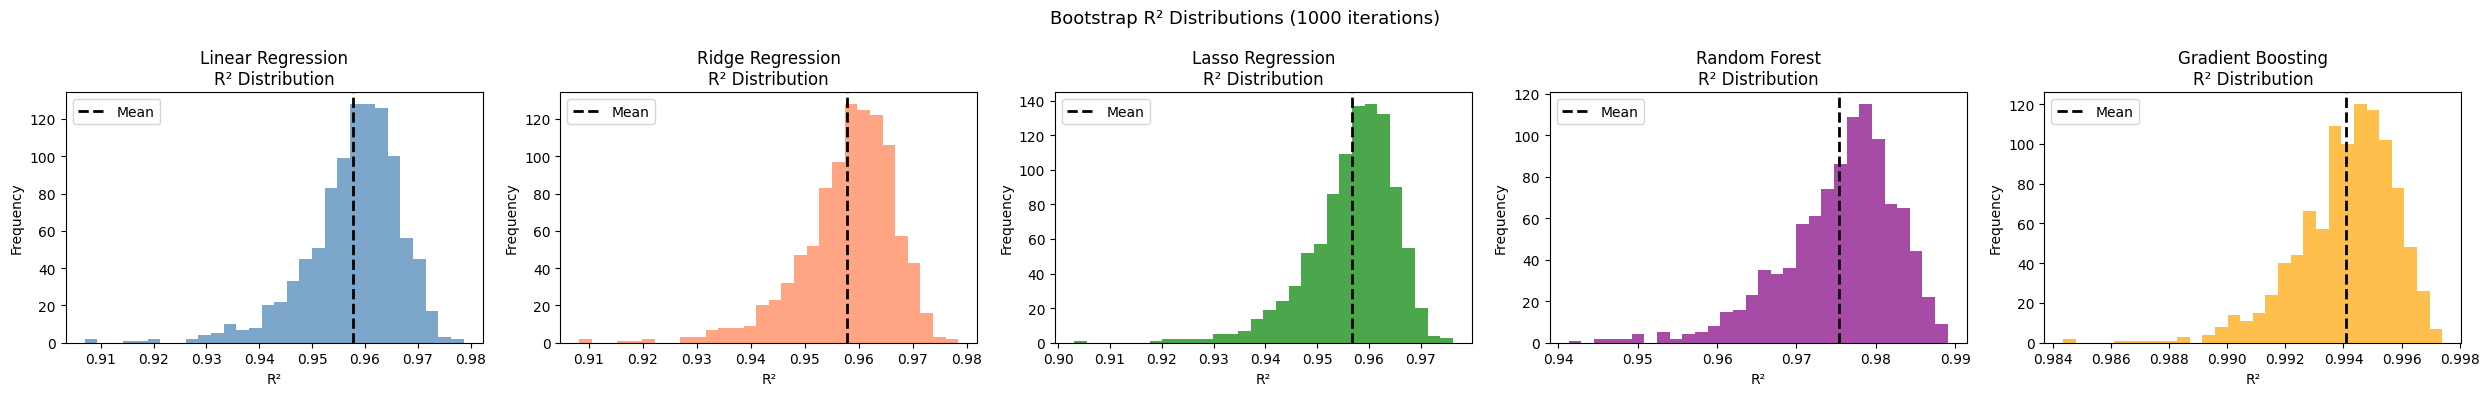

In [ ]:
import warnings
warnings.filterwarnings('ignore')
# ==========================================
# PHASE 6: BOOTSTRAP EVALUATION
# ==========================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
N_BOOTSTRAPS = 1000

# Models to evaluate
boot_models = trained_models  # use already fitted models from Phase 5
# Store results
boot_results = {name: {'R2': [], 'RMSE': [], 'MAE': []} for name in boot_models}

# Convert test set to numpy for easier indexing
# FIX: We define BOTH test sets as arrays to handle the split pipelines
X_test_linear_arr = X_test_linear_scaled.values
X_test_full_arr = X_test_full_scaled.values
y_test_arr = y_test_linear.values
n_test = len(y_test_arr)

for i in range(N_BOOTSTRAPS):
    # Draw bootstrap sample from real test set (with replacement)
    indices = np.random.choice(n_test, size=n_test, replace=True)

    y_boot = y_test_arr[indices]

    for name, model in boot_models.items():
        # FIX: Select the correct features based on the model
        if name in linear_models:
            X_boot = X_test_linear_arr[indices]
        else:
            X_boot = X_test_full_arr[indices]

        # Model is already trained - just evaluate on bootstrap sample
        y_pred = model.predict(X_boot)
        r2 = r2_score(y_boot, y_pred)
        rmse = np.sqrt(mean_squared_error(y_boot, y_pred))
        mae = mean_absolute_error(y_boot, y_pred)

        boot_results[name]['R2'].append(r2)
        boot_results[name]['RMSE'].append(rmse)
        boot_results[name]['MAE'].append(mae)

# --- Print Summary ---
print("="*60)
print("BOOTSTRAP EVALUATION RESULTS (1000 iterations)")
print("="*60)

for name in boot_models:
    r2_arr = np.array(boot_results[name]['R2'])
    rmse_arr = np.array(boot_results[name]['RMSE'])
    mae_arr = np.array(boot_results[name]['MAE'])

    print(f"\n{name}:")
    print(f"  R²  : {r2_arr.mean():.4f} ± {r2_arr.std():.4f}  [{np.percentile(r2_arr, 2.5):.4f} - {np.percentile(r2_arr, 97.5):.4f}]")
    print(f"  RMSE: {rmse_arr.mean():.4f} ± {rmse_arr.std():.4f}  [{np.percentile(rmse_arr, 2.5):.4f} - {np.percentile(rmse_arr, 97.5):.4f}]")
    print(f"  MAE : {mae_arr.mean():.4f} ± {mae_arr.std():.4f}  [{np.percentile(mae_arr, 2.5):.4f} - {np.percentile(mae_arr, 97.5):.4f}]")

# NEW Visualise Bootstrap R² Distribution
n_models = len(boot_models)
colors = ['steelblue', 'coral', 'green', 'purple', 'orange']
plt.figure(figsize=(5*n_models, 4))

for i, name in enumerate(boot_models):
    plt.subplot(1, n_models, i+1)
    plt.hist(boot_results[name]['R2'], bins=30, color=colors[i % len(colors)], alpha=0.7)
    plt.axvline(np.mean(boot_results[name]['R2']), color='black', linestyle='--', linewidth=2, label='Mean')
    plt.title(f'{name}\nR² Distribution')
    plt.xlabel('R²')
    plt.ylabel('Frequency')
    plt.legend()

plt.suptitle('Bootstrap R² Distributions (1000 iterations)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Final Model Comparison & Conclusion
print("\n" + "="*70)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*70)

summary = []
for name in trained_models:
    # Test set metrics (from results dict in Phase 5)
    test_r2 = results[name]['R2']
    test_rmse = results[name]['RMSE']
    test_mae = results[name]['MAE']

    # Bootstrap metrics (from Phase 6)
    boot_r2 = np.mean(boot_results[name]['R2'])
    boot_rmse = np.mean(boot_results[name]['RMSE'])
    boot_r2_low = np.percentile(boot_results[name]['R2'], 2.5)
    boot_r2_high = np.percentile(boot_results[name]['R2'], 97.5)

    summary.append({
        'Model': name,
        'Test R²': round(test_r2, 4),
        'Test RMSE': round(test_rmse, 4),
        'Test MAE': round(test_mae, 4),
        'Bootstrap R²': round(boot_r2, 4),
        'Bootstrap RMSE': round(boot_rmse, 4),
        '95% CI R² Low': round(boot_r2_low, 4),
        '95% CI R² High': round(boot_r2_high, 4),
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))


FINAL MODEL COMPARISON SUMMARY
            Model  Test R²  Test RMSE  Test MAE  Bootstrap R²  Bootstrap RMSE  95% CI R² Low  95% CI R² High
Linear Regression   0.9597     1.2734    1.0311        0.9578          1.2637         0.9351          0.9710
 Ridge Regression   0.9598     1.2715    1.0299        0.9579          1.2619         0.9355          0.9708
 Lasso Regression   0.9587     1.2893    1.0452        0.9567          1.2806         0.9368          0.9690
    Random Forest   0.9775     0.9521    0.8181        0.9754          0.9526         0.9585          0.9861
Gradient Boosting   0.9945     0.4686    0.4192        0.9941          0.4678         0.9901          0.9966


SHAP ANALYSIS FOR ALL TRAINED MODELS

Generating SHAP Summary Plot for: Linear Regression...


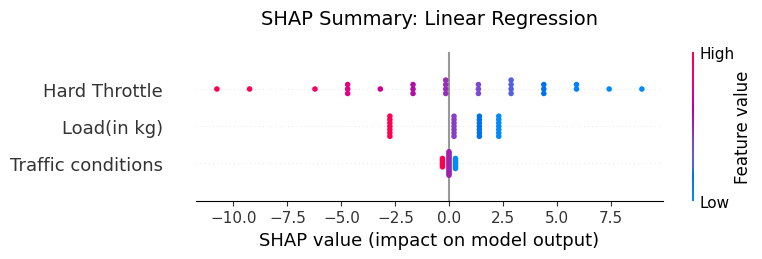


Generating SHAP Summary Plot for: Ridge Regression...


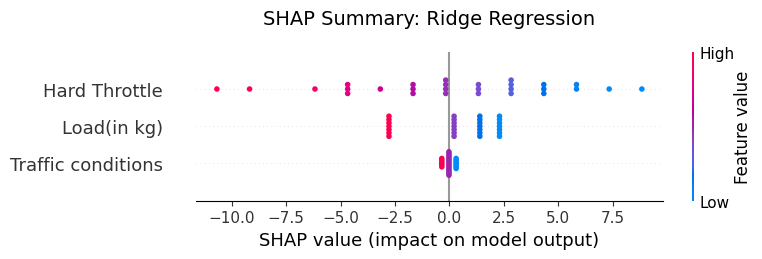


Generating SHAP Summary Plot for: Lasso Regression...


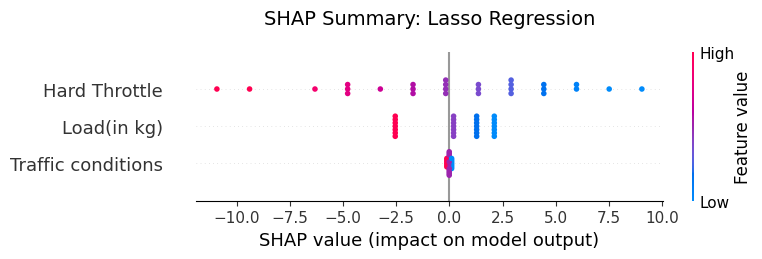


Generating SHAP Summary Plot for: Random Forest...


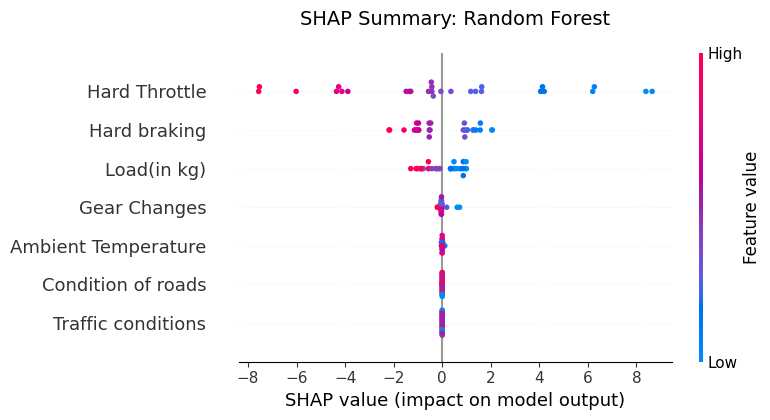


Generating SHAP Summary Plot for: Gradient Boosting...


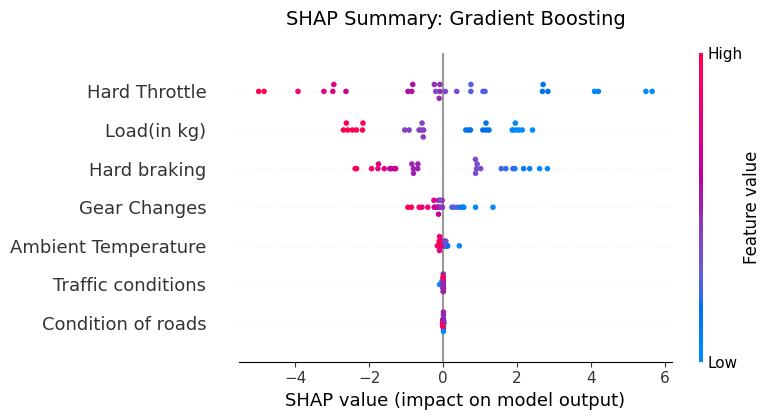

In [ ]:
# ==========================================
# PHASE 7: MODEL INTERPRETABILITY (SHAP)
# ==========================================
import shap
import matplotlib.pyplot as plt

print("="*70)
print("SHAP ANALYSIS FOR ALL TRAINED MODELS")
print("="*70)

# Iterate through all trained models to generate SHAP plots
for name, model in trained_models.items():
    print(f"\nGenerating SHAP Summary Plot for: {name}...")

    # 1. Route to the correct pipeline and explainer
    if name in linear_models:
        X_test_eval = X_test_linear_scaled
        feature_names = X_test_linear.columns
        # Linear models require a LinearExplainer and a background dataset
        explainer = shap.LinearExplainer(model, X_train_linear_scaled)
    else:
        X_test_eval = X_test_full_scaled
        feature_names = X_test_full.columns
        # Tree models use the specialized TreeExplainer
        explainer = shap.TreeExplainer(model)

    # 2. Calculate SHAP values for the test set
    shap_values = explainer.shap_values(X_test_eval)

    # 3. Generate and display the plot with a clear title
    plt.figure()
    plt.title(f"SHAP Summary: {name}", fontsize=14, pad=20)

    # Using show=False allows us to format the matplotlib figure before displaying
    shap.summary_plot(shap_values, X_test_eval, feature_names=feature_names, show=False)

    plt.tight_layout()
    plt.show()

In [ ]:
# ==========================================
# PHASE 8: INTERACTIVE MILEAGE PREDICTOR (ALL MODELS)
# ==========================================
import pandas as pd

def predict_all_models(load, road_cond, traffic, gear, throttle, braking, temp):
    """
    Predicts mileage using all 6 trained models to compare outputs.
    """
    # 1. Create the Full feature DataFrame (7 features for RF & GBM)
    df_full_input = pd.DataFrame([[load, road_cond, traffic, gear, throttle, braking, temp]],
                            columns=['Load(in kg)', 'Condition of roads', 'Traffic conditions',
                                     'Gear Changes', 'Hard Throttle', 'Hard braking', 'Ambient Temperature'])

    # 2. Create the Linear feature DataFrame (3 features for Linear, Ridge, Lasso, Curve Fit)
    df_linear_input = pd.DataFrame([[load, traffic, throttle]],
                            columns=['Load(in kg)', 'Traffic conditions', 'Hard Throttle'])

    # 3. Scale both inputs using their respective scalers from Phase 4
    input_full_scaled = scaler_full.transform(df_full_input)
    input_linear_scaled = scaler_linear.transform(df_linear_input)

    predictions = {}

    # 4. Predict using the 5 standard models
    for name, model in trained_models.items():
        if name in linear_models:
            predictions[name] = model.predict(input_linear_scaled)[0]
        else:
            predictions[name] = model.predict(input_full_scaled)[0]

    # 5. Predict using the best Curve Fitting Equation (from Phase 5.5)
    predictions['Curve Fitting (Linear)'] = lr_final.predict(input_linear_scaled)[0]

    return predictions

print("\n" + "="*60)
print("INTERACTIVE MULTI-MODEL PREDICTOR")
print("="*60)
print("Please enter the vehicle and driving conditions below.")
print("  Road Condition : 2 (Good), 1 (Average), 0 (Poor)")
print("  Traffic        : 2 (Heavy), 1 (Moderate), 0 (Light)")
print("-" * 60)

try:
    # Gather inputs dynamically
    user_load = float(input("Enter Load (in kg, e.g., 60)                 : "))
    user_road = int(input("Enter Road Condition (0, 1, or 2)            : "))
    user_traffic = int(input("Enter Traffic Condition (0, 1, or 2)         : "))
    user_gear = int(input("Enter Gear Changes (e.g., 20)                : "))
    user_throttle = float(input("Enter Hard Throttle count (e.g., 5)          : "))
    user_braking = float(input("Enter Hard Braking count (e.g., 3)           : "))
    user_temp = float(input("Enter Ambient Temperature (in C, e.g., 32)   : "))

    # Run the predictions
    all_preds = predict_all_models(user_load, user_road, user_traffic, user_gear, user_throttle, user_braking, user_temp)

    print("\n" + "="*50)
    print("MODEL PREDICTIONS:")
    print("="*50)
    for model_name, pred_val in all_preds.items():
        # Highlight Gradient Boosting since we mathematically proved it's the most accurate
        if model_name == 'Gradient Boosting':
            print(f"⭐ {model_name:25s} : {pred_val:.2f} km/l  <-- [MOST ACCURATE]")
        else:
            print(f"   {model_name:25s} : {pred_val:.2f} km/l")
    print("="*50)

except ValueError:
    print("\n[Error] Invalid input detected. Please ensure you only enter numbers.")

print("\n" + "="*60)
print("PROJECT EXECUTION COMPLETE. ALL PIPELINES SUCCESSFUL.")
print("="*60)


INTERACTIVE MULTI-MODEL PREDICTOR
Please enter the vehicle and driving conditions below.
  Road Condition : 2 (Good), 1 (Average), 0 (Poor)
  Traffic        : 2 (Heavy), 1 (Moderate), 0 (Light)
------------------------------------------------------------
